# Pipeline de Classificação LULC — Sentinel-2 + MapBiomas
**Região:** Sapezal (MT) · **Período:** seca 2023 (Jun–Set) · **Classificador:** Random Forest (GEE) + scikit-learn/XGBoost

Todo processamento de imagem é executado **server-side no Google Earth Engine**.  
O Colab/local lida apenas com tabelas de amostras leves e visualizações.

---
## Etapa 1 — Setup do Ambiente

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_URL    = 'https://github.com/ferdamarc/LULC_project.git'
    REPO_BRANCH = 'dev'
    PROJECT_DIR = '/content/LULC_project'

    if not os.path.exists(PROJECT_DIR):
        os.system(f'git clone --branch {REPO_BRANCH} {REPO_URL} {PROJECT_DIR}')
    else:
        os.system(f'git -C {PROJECT_DIR} checkout {REPO_BRANCH}')
        os.system(f'git -C {PROJECT_DIR} pull origin {REPO_BRANCH} --quiet')

    os.chdir(f'{PROJECT_DIR}/notebooks')
    os.system('pip install -r ../requirements.txt -q')
    sys.path.insert(0, f'{PROJECT_DIR}/src')
    print(f'Colab: projeto carregado de {PROJECT_DIR} (branch: {REPO_BRANCH})')

else:
    _cwd = Path(os.getcwd())
    _root = next(
        (p for p in [_cwd] + list(_cwd.parents) if (p / 'environment.yml').exists()),
        _cwd.parent,
    )
    sys.path.insert(0, str(_root / 'src'))
    os.chdir(_root / 'notebooks')
    print(f'Local: usando ambiente Conda lulc-project')
    print(f'Raiz do projeto: {_root}')

Local: usando ambiente Conda lulc-project
Raiz do projeto: /home/fernando-daniel-marcelino/workspace/projects/LULC_project


In [2]:
# autoreload: recarrega módulos de src/ automaticamente quando editados,
# sem precisar reiniciar o kernel ou fazer importlib.reload manual
%load_ext autoreload
%autoreload 2

import sys
import os

IN_COLAB = 'google.colab' in sys.modules

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, cohen_kappa_score,
)
import xgboost as xgb
from pathlib import Path

if IN_COLAB:
    import google.colab.userdata as _ud
    _orig_ud_get = _ud.get
    def _safe_ud_get(key):
        try:
            return _orig_ud_get(key)
        except Exception:
            return None
    _ud.get = _safe_ud_get

from gee_utils import build_s2_composite, load_mapbiomas, FEATURE_BANDS

print(f"ee: {ee.__version__} | geemap: {geemap.__version__}")
print(f"Feature bands ({len(FEATURE_BANDS)}): {FEATURE_BANDS}")

ee: 1.7.31 | geemap: 0.37.2
Feature bands (14): ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'EVI', 'SAVI']


In [ ]:
from pathlib import Path

# ID do Google Cloud Project com a Earth Engine API habilitada.
# Lido de variável de ambiente para NÃO deixar o ID fixo no código versionado.
#   Local : export GEE_PROJECT='seu-projeto'  (antes de iniciar o Jupyter)
#   Colab : import os; os.environ['GEE_PROJECT'] = 'seu-projeto'
#           ou via Colab Secrets (userdata) na célula de setup.
GEE_PROJECT = os.environ.get('GEE_PROJECT', 'seu-projeto-gcp')
if GEE_PROJECT == 'seu-projeto-gcp':
    raise ValueError(
        "Defina a variável de ambiente GEE_PROJECT com o ID do seu Google Cloud Project."
    )

# Autentica apenas se não houver credenciais em cache.
# Localmente: rode `earthengine authenticate` no terminal uma vez (salva em ~/.config/earthengine/).
# No Colab: ee.Authenticate() abre o fluxo OAuth interativo a cada sessão.
_creds_path = Path.home() / '.config' / 'earthengine' / 'credentials'
if not _creds_path.exists():
    ee.Authenticate()

ee.Initialize(project=GEE_PROJECT)
print('GEE inicializado com sucesso.')

---
## Etapa 2 — Definição da AOI e Configuração do Projeto

In [4]:
# =============================================================================
# Bloco de configuração central — todos os parâmetros do projeto em um lugar.
# Etapas subsequentes leem daqui; não repetir essas constantes nas células abaixo.
# =============================================================================

# --- AOI ---
# Bbox de ~2.400 km² (≈50 km × 50 km) sobre a zona agrícola de Sapezal (MT).
# BBox(west, south, east, north)
AOI = ee.Geometry.BBox(-59.20, -13.85, -58.70, -13.35)

# --- Período temporal ---
START_DATE = '2023-06-01'
END_DATE   = '2023-09-30'

# --- Classes LULC do projeto ---
# Chave: código interno do projeto (1-6)
# 'mapbiomas': lista de códigos MapBiomas Collection 9 que mapeiam para essa classe
# 'color': hex para visualização no mapa
LULC_CLASSES = {
    1: {'name': 'Floresta',                  'mapbiomas': [3],                    'color': '#1f7a1f'},
    2: {'name': 'Cerrado/Savana',            'mapbiomas': [4, 12],                'color': '#d4a028'},
    3: {'name': 'Pastagem',                  'mapbiomas': [15],                   'color': '#b8af4f'},
    4: {'name': 'Agricultura',               'mapbiomas': [18, 21, 39, 40, 41],   'color': '#f5e642'},
    5: {'name': 'Água',                      'mapbiomas': [11, 31, 33],           'color': '#2d6fd3'},
    6: {'name': 'Solo Exposto/Não Vegetado', 'mapbiomas': [24, 25, 30],           'color': '#c49a6c'},
}
# Códigos adicionados em relação à definição inicial:
#   11 (Área Úmida) → Água:       campos alagados às margens do Juruena/Papagaio
#   21 (Mosaico Agropecuário) → Agricultura: mistura de lavoura e pasto, predominante no Cerrado

# Lookup inverso: código MapBiomas → código do projeto (usado na Etapa 5)
MB_TO_LULC = {
    mb_code: proj_code
    for proj_code, info in LULC_CLASSES.items()
    for mb_code in info['mapbiomas']
}

# Listas paralelas para ee.Image.remap (espera listas, não dicts)
MB_FROM = list(MB_TO_LULC.keys())
MB_TO   = list(MB_TO_LULC.values())

print('Configuração carregada.')
print(f'AOI: {AOI.bounds().getInfo()}')
print(f'Período: {START_DATE} → {END_DATE}')
print(f'Classes: {", ".join(v["name"] for v in LULC_CLASSES.values())}')
print(f'Códigos MapBiomas mapeados: {MB_FROM}')

Configuração carregada.
AOI: {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-59.19999999999999, -13.85], [-58.69999999999999, -13.85], [-58.69999999999999, -13.35], [-59.19999999999999, -13.35], [-59.19999999999999, -13.85]]]}
Período: 2023-06-01 → 2023-09-30
Classes: Floresta, Cerrado/Savana, Pastagem, Agricultura, Água, Solo Exposto/Não Vegetado
Códigos MapBiomas mapeados: [3, 4, 12, 15, 18, 21, 39, 40, 41, 11, 31, 33, 24, 25, 30]


In [5]:
# Calcula a área da AOI server-side (evita .getInfo() em geometrias complexas)
area_km2 = AOI.area(maxError=100).divide(1e6).getInfo()
print(f'Área da AOI: {area_km2:.0f} km²')

Área da AOI: 3004 km²


In [6]:
Map = geemap.Map(center=[-13.60, -58.95], zoom=10)
Map.addLayer(AOI, {'color': 'red', 'fillColor': '00000000'}, 'AOI — Sapezal (MT)')
Map.add_basemap('Esri.WorldImagery')
Map

Map(center=[-13.6, -58.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

**Verificação antes de avançar:**
- O contorno vermelho cobre a zona agrícola de Sapezal? (deve mostrar talhões de soja/pastagem no basemap de satélite)
- A área calculada está em ~2.400 km²?
- O GEE não retornou erro de quota ou autenticação?

Se tudo OK, avance para a Etapa 3.

---
## Etapa 3 — Carregamento e Pré-processamento do Sentinel-2

**Coleção:** `COPERNICUS/S2_SR_HARMONIZED` (SR = Surface Reflectance, Harmonized = offset radiométrico entre S2A/S2B corrigido)  
**Período:** Jun–Set 2023 · **Filtro:** `CLOUDY_PIXEL_PERCENTAGE < 20%` · **Composite:** mediana

In [7]:
s2_composite = build_s2_composite(AOI, START_DATE, END_DATE, max_cloud_pct=20)

# Conta quantas cenas entraram na composição (chamada leve ao GEE)
n_scenes = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(AOI)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .size()
    .getInfo()
)
print(f'Cenas disponíveis para composição: {n_scenes}')
print(f'Bandas no composite: {s2_composite.bandNames().getInfo()}')

Cenas disponíveis para composição: 71
Bandas no composite: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'EVI', 'SAVI']


In [8]:
# Visualização do composite — duas composições lado a lado como camadas alternáveis
Map_s2 = geemap.Map(center=[-13.60, -58.95], zoom=11)

# Cores verdadeiras: útil para reconhecimento visual das feições (talhões, rios, mata)
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0.0, 'max': 0.25, 'gamma': 1.4}
Map_s2.addLayer(s2_composite, vis_rgb, 'RGB — Cores verdadeiras')

# Falsa cor infravermelha: vegetação ativa aparece em vermelho (NIR no canal R)
# Útil para distinguir Floresta (vermelho vivo) de Pastagem/Solo (tons de rosa/bege)
vis_fci = {'bands': ['B8', 'B4', 'B3'], 'min': 0.0, 'max': 0.45, 'gamma': 1.3}
Map_s2.addLayer(s2_composite, vis_fci, 'Falsa Cor Infravermelha (NIR-R-G)')

Map_s2.addLayer(AOI, {'color': 'white', 'fillColor': '00000000'}, 'AOI')
Map_s2.add_basemap('Esri.WorldImagery')
Map_s2

Map(center=[-13.6, -58.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

**Verificação antes de avançar para a Etapa 4:**
- `n_scenes` deve ser ≥ 10 (seca de MT costuma ter 15–30 cenas com <20% nuvem)
- No mapa RGB, talhões agrícolas aparecem em tons de bege/ocre (solo exposto pós-colheita)
- Na falsa cor IR, áreas de floresta aparecem em vermelho intenso; pastagem em rosa claro

Se o mapa aparecer completamente cinza ou com muitos pixels ausentes, reduza `max_cloud_pct` para 30 ou expanda o período para Mai–Out 2023.

---
## Etapa 4 — Índices Espectrais

Os índices já foram calculados dentro de `build_s2_composite` (via `add_spectral_indices`).  
Esta etapa os visualiza e valida os intervalos esperados por classe antes de prosseguir para a amostragem.

In [9]:
Map_idx = geemap.Map(center=[-13.60, -58.95], zoom=11)

# NDVI: vermelho (baixo) → amarelo → verde escuro (alto)
# Na seca: Floresta ~0.7-0.9 | Cerrado ~0.4-0.7 | Pastagem ~0.3-0.5 | Solo Exposto <0.2
vis_ndvi = {
    'bands': ['NDVI'], 'min': -0.1, 'max': 0.9,
    'palette': ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#d9ef8b', '#a6d96a', '#1a9850'],
}
Map_idx.addLayer(s2_composite, vis_ndvi, 'NDVI')

# NDWI: azul escuro = água (NDWI > 0), bege = terra seca (NDWI < 0)
vis_ndwi = {
    'bands': ['NDWI'], 'min': -0.5, 'max': 0.3,
    'palette': ['#d7191c', '#fdae61', '#ffffbf', '#abd9e9', '#2c7bb6'],
}
Map_idx.addLayer(s2_composite, vis_ndwi, 'NDWI')

Map_idx.addLayer(AOI, {'color': 'white', 'fillColor': '00000000'}, 'AOI')
Map_idx.add_basemap('Esri.WorldImagery')
Map_idx

Map(center=[-13.6, -58.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

**Verificação antes de avançar para a Etapa 5:**
- **NDVI:** rios e áreas urbanas aparecem em vermelho (<0.1); talhões colhidos em laranja/amarelo (0.1–0.3); pastagem em amarelo-esverdeado (0.3–0.5); mata em verde escuro (>0.6)
- **NDWI:** calha dos rios Juruena/Papagaio deve aparecer em azul escuro (>0) — boa sanidade check da banda de água
- Se os índices aparecerem fora de escala (tudo branco ou tudo preto), é sinal de que a divisão por 10 000 não foi aplicada — verifique se `mask_s2_clouds` está sendo chamada na coleção

---
## Etapa 5 — MapBiomas: Carregamento e Reclassificação

**Asset:** MapBiomas Collection 9 · **Ano:** 2023 · **Resolução:** 30 m (derivado do Landsat)  
A imagem do MapBiomas é uma `ee.Image` com uma banda por ano. Selecionamos `classification_2023` e remapeamos os códigos originais para as 6 classes do projeto.

In [10]:
lulc_mapbiomas = load_mapbiomas(AOI, MB_FROM, MB_TO, year=2023)

# Paleta indexada: a cor da posição i corresponde ao valor (min + i)
# min=1 → [Floresta, Cerrado, Pastagem, Agricultura, Água, Solo Exposto]
vis_lulc = {
    'min': 1, 'max': 6,
    'palette': [info['color'] for info in LULC_CLASSES.values()],
}

Map_mb = geemap.Map(center=[-13.60, -58.95], zoom=11)
Map_mb.addLayer(s2_composite,  {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25, 'gamma': 1.4}, 'S2 RGB')
Map_mb.addLayer(lulc_mapbiomas, vis_lulc, 'MapBiomas 2023 — reclassificado')
Map_mb.addLayer(AOI, {'color': 'white', 'fillColor': '00000000'}, 'AOI')

# Legenda das classes
legend_dict = {info['name']: info['color'] for info in LULC_CLASSES.values()}
Map_mb.add_legend(title='Classes LULC', legend_dict=legend_dict, position='bottomright')

Map_mb

Map(center=[-13.6, -58.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

                   Classe  Área (km²)  Proporção (%)
              Agricultura      2205.6           71.4
                 Floresta       506.0           16.4
           Cerrado/Savana       325.0           10.5
                 Pastagem        21.4            0.7
Solo Exposto/Não Vegetado        21.2            0.7
                     Água         8.0            0.3

Área total mapeada: 3087 km²


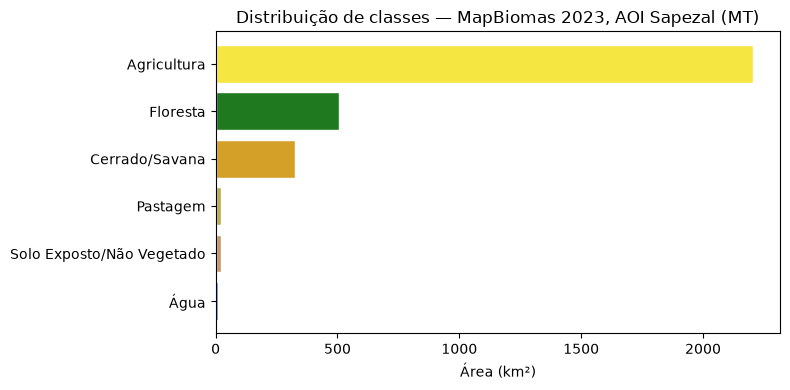

In [11]:
# Distribuição de área por classe — validação antes de amostrar
# ⚠️ Pode levar 10-30s: reduceRegion sobre ~2.7M pixels a 30m
# Se timeout: aumente scale para 100 ou use bestEffort=True (já ativo)
freq_result = lulc_mapbiomas.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=AOI,
    scale=30,
    maxPixels=1e9,
    bestEffort=True,
).getInfo()

pixel_area_km2 = (30 * 30) / 1e6  # cada pixel = 900 m² = 0.0009 km²

records = [
    {
        'Classe': LULC_CLASSES[int(float(k))]['name'],
        'Área (km²)': round(v * pixel_area_km2, 1),
        'Proporção (%)': None,
        'Cor': LULC_CLASSES[int(float(k))]['color'],
    }
    for k, v in freq_result['lulc'].items()
    if int(float(k)) in LULC_CLASSES
]

df_dist = pd.DataFrame(records).sort_values('Área (km²)', ascending=False).reset_index(drop=True)
total = df_dist['Área (km²)'].sum()
df_dist['Proporção (%)'] = (df_dist['Área (km²)'] / total * 100).round(1)

print(df_dist[['Classe', 'Área (km²)', 'Proporção (%)']].to_string(index=False))
print(f'\nÁrea total mapeada: {total:.0f} km²')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_dist['Classe'], df_dist['Área (km²)'], color=df_dist['Cor'], edgecolor='white')
ax.set_xlabel('Área (km²)')
ax.set_title('Distribuição de classes — MapBiomas 2023, AOI Sapezal (MT)')
ax.invert_yaxis()
plt.tight_layout()

output_path = Path('../outputs/figuras/distribuicao_classes_mapbiomas.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

**Verificação antes de avançar para a Etapa 6 (amostragem):**
- Todas as 6 classes devem aparecer na tabela — se alguma estiver ausente, a AOI não contém aquela cobertura e precisamos ajustar o bbox ou fundir classes
- **Distribuição esperada para Sapezal 2023:** Agricultura > Pastagem >> Cerrado/Savana ≈ Floresta > Solo Exposto > Água
- No mapa: alterne entre "S2 RGB" e "MapBiomas reclassificado" para validar visualmente se as cores fazem sentido sobre a imagem de satélite
- Se a figura não foi salva em `outputs/figuras/`: verifique se o diretório existe com `!ls ../outputs/figuras/`
- Se receber `EEException: Asset not found`: o asset ID da Collection 9 mudou — busque "MapBiomas" no [GEE Data Catalog](https://developers.google.com/earth-engine/datasets) e atualize `load_mapbiomas` em `src/gee_utils.py`

---
## Etapa 6 — Amostragem Estratificada

`stratifiedSample` combina lulc (MapBiomas) + composite (Sentinel-2) server-side e extrai
N pontos por classe com os valores espectrais já incluídos — sem transferir pixels para o local.
Split treino/teste feito no GEE com `randomColumn` antes de baixar os dados.

In [12]:
from sampling import stratified_sample, train_test_split, fc_to_dataframe

# Amostras por classe — ajuste se uma classe tiver área muito pequena na AOI
N_PER_CLASS = 200

# ⚠️ Pode levar 30-60s: stratifiedSample combina lulc + 14 bandas server-side
samples_all = stratified_sample(lulc_mapbiomas, s2_composite, AOI, n_per_class=N_PER_CLASS)

# Valida contagem real por classe (GEE retorna menos que N se a classe tiver poucos pixels)
count_by_class = (
    samples_all
    .aggregate_histogram('lulc')
    .getInfo()
)
print(f'Total de amostras: {samples_all.size().getInfo()}')
print('\nAmostras por classe:')
for code_str, count in sorted(count_by_class.items(), key=lambda x: int(x[0])):
    name = LULC_CLASSES[int(float(code_str))]['name']
    print(f'  {int(float(code_str))} — {name:<30} {int(count):>4} amostras')

Total de amostras: 1200

Amostras por classe:
  1 — Floresta                        200 amostras
  2 — Cerrado/Savana                  200 amostras
  3 — Pastagem                        200 amostras
  4 — Agricultura                     200 amostras
  5 — Água                            200 amostras
  6 — Solo Exposto/Não Vegetado       200 amostras


In [13]:
# Split treino/teste no GEE (80/20) e conversão para pandas
# getInfo() é seguro aqui: ~1200 amostras × 15 colunas é trivial para transferir
train_fc, test_fc = train_test_split(samples_all, train_ratio=0.8, seed=42)

print('Baixando amostras do GEE... (pode levar ~20s)')
df_train = fc_to_dataframe(train_fc, FEATURE_BANDS)
df_test  = fc_to_dataframe(test_fc,  FEATURE_BANDS)

print(f'\nTreino: {len(df_train)} amostras | Teste: {len(df_test)} amostras')

# Distribuição por classe no treino (valida que o split não desequilibrou as classes)
print('\nDistribuição no treino:')
train_dist = df_train['lulc'].value_counts().sort_index()
for code, count in train_dist.items():
    print(f'  {int(code)} — {LULC_CLASSES[int(code)]["name"]:<30} {count:>4}')

# Salva CSVs para reprodutibilidade — evita rodar o GEE novamente em análises futuras
output_dir = Path('../outputs/metricas')
output_dir.mkdir(parents=True, exist_ok=True)
df_train.to_csv(output_dir / 'amostras_treino.csv', index=False)
df_test.to_csv( output_dir / 'amostras_teste.csv',  index=False)
print(f'\nCSVs salvos em {output_dir.resolve()}')

Baixando amostras do GEE... (pode levar ~20s)

Treino: 939 amostras | Teste: 261 amostras

Distribuição no treino:
  1 — Floresta                        152
  2 — Cerrado/Savana                  167
  3 — Pastagem                        153
  4 — Agricultura                     159
  5 — Água                            156
  6 — Solo Exposto/Não Vegetado       152

CSVs salvos em /home/fernando-daniel-marcelino/workspace/projects/LULC_project/outputs/metricas


**Verificação antes de avançar para a Etapa 7 (treinamento):**
- Total de amostras deve ser próximo de 1.200 (6 classes × 200). Se uma classe ficou muito abaixo (< 50), ela tem poucos pixels na AOI — considere fundir com classe vizinha ou reduzir `N_PER_CLASS` para equilibrar.
- Água e Solo Exposto são as classes com menor área na AOI — são as mais prováveis de ter menos de 200 amostras.
- Os CSVs em `outputs/metricas/` permitem re-rodar o treinamento (Etapas 7–8) sem precisar do GEE.

---
## Etapa 7 — Treinamento do Classificador

Dois caminhos paralelos:
- **GEE RF:** `ee.Classifier.smileRandomForest` — treina server-side no `train_fc`, gera o mapa classificado na Etapa 9
- **sklearn RF + XGBoost:** treina localmente nos CSVs de `outputs/metricas/`, mais controle sobre hiperparâmetros

In [14]:
from evaluation import plot_feature_importance, compute_metrics

# Carrega dos CSVs — permite re-rodar esta etapa sem refazer a amostragem no GEE
df_train = pd.read_csv('../outputs/metricas/amostras_treino.csv')
df_test  = pd.read_csv('../outputs/metricas/amostras_teste.csv')

X_train = df_train[FEATURE_BANDS].values
y_train = df_train['lulc'].astype(int).values
X_test  = df_test[FEATURE_BANDS].values
y_test  = df_test['lulc'].astype(int).values

CLASS_NAMES = [info['name'] for info in LULC_CLASSES.values()]

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Classes: {CLASS_NAMES}')

X_train: (939, 14) | X_test: (261, 14)
Classes: ['Floresta', 'Cerrado/Savana', 'Pastagem', 'Agricultura', 'Água', 'Solo Exposto/Não Vegetado']


In [15]:
# --- Caminho 1: GEE Random Forest ---
# Treina server-side no train_fc (requer Etapa 6 executada na mesma sessão).
# O objeto gee_classifier é usado na Etapa 9 para gerar o mapa classificado.
# ⚠️ Se o kernel foi reiniciado, execute as células da Etapa 6 antes desta.

gee_classifier = (
    ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42)
    .train(
        features=train_fc,
        classProperty='lulc',
        inputProperties=FEATURE_BANDS,
    )
)

# Avalia no conjunto de teste via GEE (errorMatrix calcula a matriz de confusão server-side)
test_classified_gee = test_fc.classify(gee_classifier)
gee_error_matrix = test_classified_gee.errorMatrix(
    actual='lulc',
    predicted='classification',
    order=list(LULC_CLASSES.keys()),
)
gee_accuracy = gee_error_matrix.accuracy().getInfo()
gee_kappa    = gee_error_matrix.kappa().getInfo()

print('=== GEE Random Forest ===')
print(f'Acurácia global (teste): {gee_accuracy:.4f}')
print(f'Kappa           (teste): {gee_kappa:.4f}')

=== GEE Random Forest ===
Acurácia global (teste): 0.8199
Kappa           (teste): 0.7835


In [16]:
# --- Caminho 2: sklearn Random Forest + XGBoost ---

# sklearn RF
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== sklearn Random Forest ===')
print(f'Acurácia global (teste): {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Kappa           (teste): {cohen_kappa_score(y_test, y_pred_rf):.4f}')

# XGBoost exige labels iniciando em 0 — convertemos 1-6 → 0-5 para o fit
xgb_clf = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_clf.fit(X_train, y_train - 1)
y_pred_xgb = xgb_clf.predict(X_test) + 1  # reverte 0-5 → 1-6

print('\n=== XGBoost ===')
print(f'Acurácia global (teste): {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Kappa           (teste): {cohen_kappa_score(y_test, y_pred_xgb):.4f}')

=== sklearn Random Forest ===
Acurácia global (teste): 0.8238
Kappa           (teste): 0.7880

=== XGBoost ===
Acurácia global (teste): 0.8199
Kappa           (teste): 0.7834


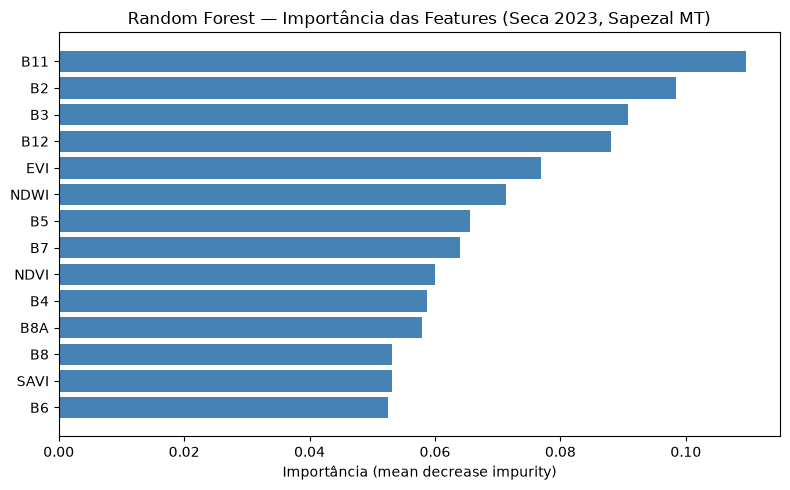

Modelos salvos em outputs/metricas/


In [17]:
# Importância das features do RF — sanity check: NDVI/EVI devem liderar
fig_imp = plot_feature_importance(
    rf.feature_importances_, FEATURE_BANDS,
    title='Random Forest — Importância das Features (Seca 2023, Sapezal MT)',
)
fig_imp.savefig('../outputs/figuras/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# Salva modelos para reutilização na Etapa 8 sem re-treinar
import joblib
joblib.dump(rf, '../outputs/metricas/rf_model.pkl')
xgb_clf.save_model('../outputs/metricas/xgb_model.json')
print('Modelos salvos em outputs/metricas/')

**Verificação antes de avançar para a Etapa 8 (validação completa):**
- **Acurácias esperadas** para esse cenário (seca 2023, 6 classes bem separadas espectralmente): RF ≥ 0.85, XGBoost ≥ 0.85, GEE RF próximo ao sklearn RF
- **Kappa esperado:** ≥ 0.80 — abaixo de 0.60 indica problema nas amostras ou nas features
- **Importância das features:** NDVI e EVI devem aparecer entre os 3 primeiros — se bandas SWIR (B11/B12) liderarem, pode indicar confusão entre Solo Exposto e Agricultura
- Se as acurácias ficarem abaixo de 0.75, as causas mais prováveis são: classes Pastagem ↔ Cerrado/Savana sendo confundidas (espectro similar na seca) ou amostras de borda de talhão no MapBiomas

---
## Etapa 8 — Validação: Matriz de Confusão, Kappa, F1-score por Classe

Avalia os três modelos no conjunto de teste usando as funções de `src/evaluation.py`.  
Os modelos sklearn/XGBoost são carregados dos arquivos salvos (permite re-rodar sem re-treinar).

In [18]:
import joblib
from evaluation import compute_metrics, plot_confusion_matrix, compare_models

# Carrega modelos dos arquivos — funciona mesmo se o kernel foi reiniciado
rf_model = joblib.load('../outputs/metricas/rf_model.pkl')

xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../outputs/metricas/xgb_model.json')

# Re-carrega dados de teste dos CSVs (caso kernel reiniciado)
df_test  = pd.read_csv('../outputs/metricas/amostras_teste.csv')
X_test   = df_test[FEATURE_BANDS].values
y_test   = df_test['lulc'].astype(int).values
CLASS_NAMES = [info['name'] for info in LULC_CLASSES.values()]

y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test) + 1   # reverte 0-5 → 1-6

print('Modelos e predições prontos.')

Modelos e predições prontos.


In [19]:
# Métricas completas — sklearn RF e XGBoost
metrics_rf,  report_rf  = compute_metrics(y_test, y_pred_rf,  CLASS_NAMES)
metrics_xgb, report_xgb = compute_metrics(y_test, y_pred_xgb, CLASS_NAMES)

# GEE RF: accuracy e kappa já calculados na Etapa 7 via errorMatrix
# f1_macro não disponível diretamente no GEE sem chamada adicional
metrics_gee = {
    'accuracy':    gee_accuracy,
    'kappa':       gee_kappa,
    'f1_macro':    float('nan'),
    'f1_weighted': float('nan'),
}

df_summary = pd.DataFrame({
    'GEE RF':     metrics_gee,
    'sklearn RF': metrics_rf,
    'XGBoost':    metrics_xgb,
}).T[['accuracy', 'kappa', 'f1_macro', 'f1_weighted']].round(4)

print('=== Resumo — todos os modelos ===')
print(df_summary.to_string())

df_summary.to_csv('../outputs/metricas/resumo_modelos.csv')
print('\nSalvo em outputs/metricas/resumo_modelos.csv')

=== Resumo — todos os modelos ===
            accuracy   kappa  f1_macro  f1_weighted
GEE RF        0.8199  0.7835       NaN          NaN
sklearn RF    0.8238  0.7880    0.8224       0.8245
XGBoost       0.8199  0.7834    0.8210       0.8206

Salvo em outputs/metricas/resumo_modelos.csv


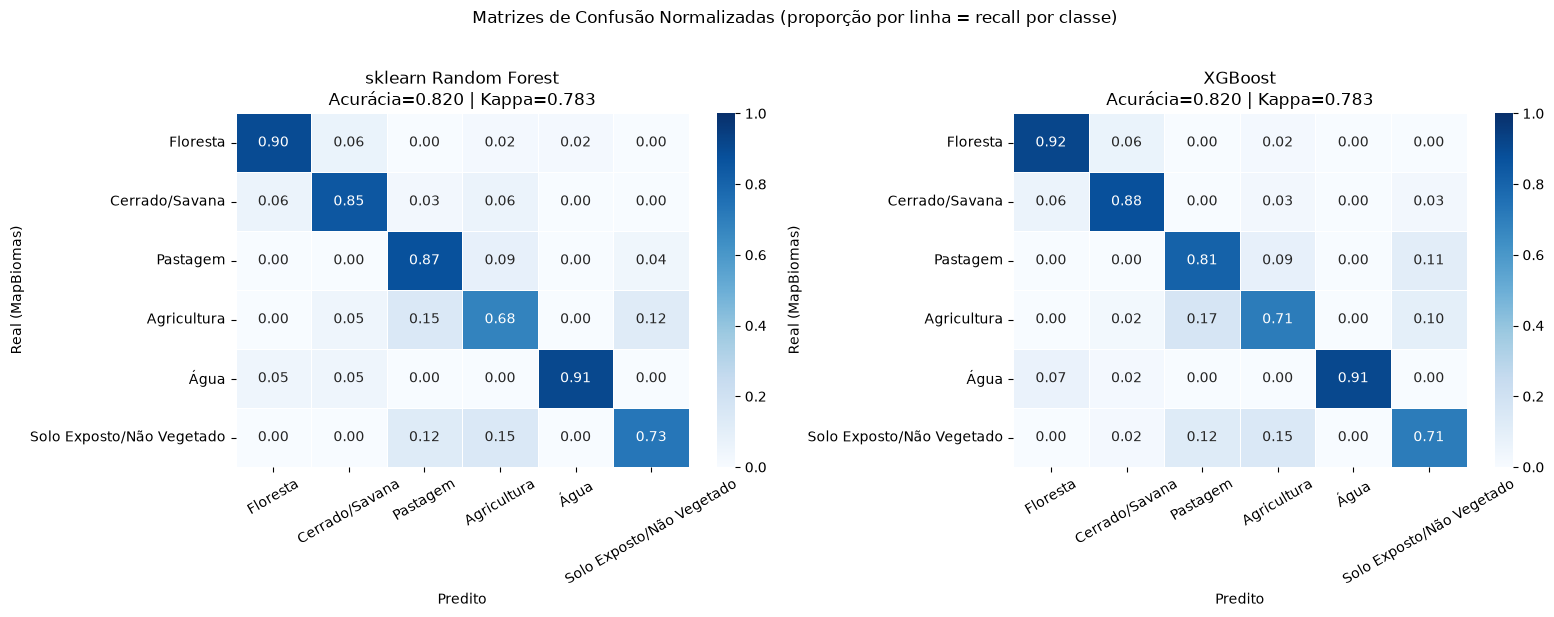

In [20]:
# Matrizes de confusão — sklearn RF e XGBoost lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['sklearn Random Forest', 'XGBoost'],
):
    from sklearn.metrics import confusion_matrix
    import numpy as np
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    import seaborn as sns
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
    )
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real (MapBiomas)')
    ax.set_title(f'{title}\nAcurácia={metrics_rf["accuracy"]:.3f} | Kappa={metrics_rf["kappa"]:.3f}'
                 if 'RF' in title
                 else f'{title}\nAcurácia={metrics_xgb["accuracy"]:.3f} | Kappa={metrics_xgb["kappa"]:.3f}')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Matrizes de Confusão Normalizadas (proporção por linha = recall por classe)',
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig('../outputs/figuras/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

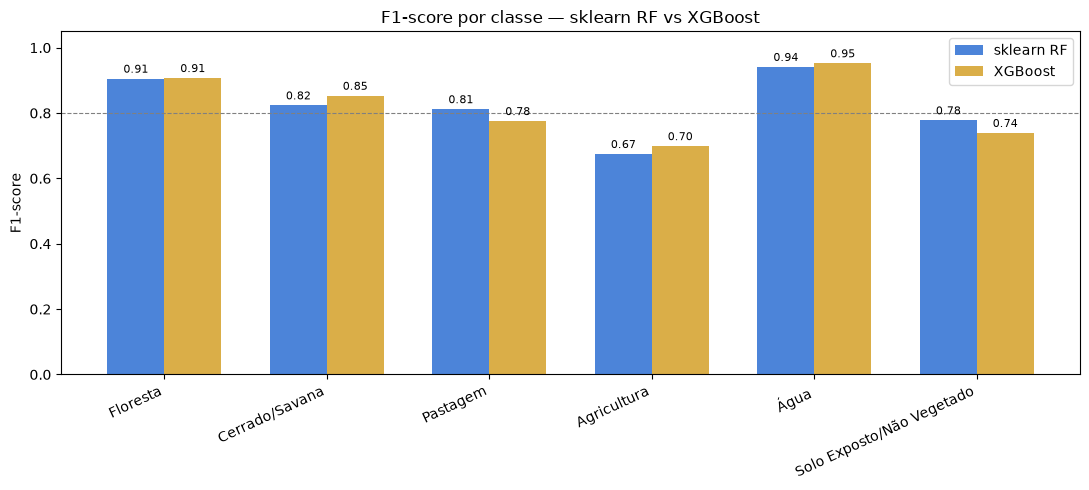

Relatórios salvos em outputs/metricas/


In [21]:
# F1-score por classe — RF vs XGBoost
f1_rf  = report_rf.loc[CLASS_NAMES,  'f1-score'].values
f1_xgb = report_xgb.loc[CLASS_NAMES, 'f1-score'].values

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_rf  = ax.bar(x - width / 2, f1_rf,  width, label='sklearn RF',  color='#2d6fd3', alpha=0.85)
bars_xgb = ax.bar(x + width / 2, f1_xgb, width, label='XGBoost',     color='#d4a028', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.set_title('F1-score por classe — sklearn RF vs XGBoost')
ax.legend()
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8, label='limiar 0.80')

# Anota o valor em cada barra
for bar in list(bars_rf) + list(bars_xgb):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig('../outputs/figuras/f1_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

# Relatórios detalhados em CSV
report_rf.to_csv('../outputs/metricas/metricas_rf.csv')
report_xgb.to_csv('../outputs/metricas/metricas_xgb.csv')
print('Relatórios salvos em outputs/metricas/')

**Como ler os resultados:**
- **Diagonal principal da matriz de confusão** = recall por classe (quanto da classe real foi classificado corretamente). Valores altos na diagonal = modelo bom.
- **Fora da diagonal** = confusões — leia por linha: "X% dos pixels reais de *Classe A* foram classificados erroneamente como *Classe B*".
- **Confusões esperadas** para seca de 2023: Agricultura ↔ Solo Exposto (soja colhida = solo nu), Pastagem ↔ Cerrado/Savana (ambos com NDVI baixo a moderado na seca).
- **F1-score < 0.70** em alguma classe = sinal de que vale investigar mais amostras ou ajustar a reclassificação do MapBiomas para aquela classe.

Compartilhe a tabela de resumo e os valores de F1 por classe para interpretarmos juntos antes de avançar para a Etapa 9 (mapa classificado).

---
## Etapa 9 — Visualização dos Resultados

Aplica o `gee_classifier` (GEE RF) ao composite Sentinel-2 completo para gerar o mapa LULC classificado.
Visualiza classificado vs MapBiomas (referência) e calcula o mapa de concordância/erro por pixel.

In [22]:
# Aplica o classificador GEE ao composite completo (toda a AOI, não só os pontos de teste)
# ⚠️ Requer gee_classifier definido na Etapa 7 — re-execute aquela célula se reiniciou o kernel
classified_map = (
    s2_composite
    .classify(gee_classifier)
    .updateMask(lulc_mapbiomas.mask())   # restringe à área com referência MapBiomas válida
    .rename('lulc')
)

# Paleta compartilhada entre classificado e referência
vis_lulc = {
    'min': 1, 'max': 6,
    'palette': [info['color'] for info in LULC_CLASSES.values()],
}

# Split map — slider interativo para comparar classificado vs referência
left_layer  = geemap.ee_tile_layer(classified_map,  vis_lulc, 'GEE RF Classificado')
right_layer = geemap.ee_tile_layer(lulc_mapbiomas,  vis_lulc, 'MapBiomas 2023 (referência)')

Map_split = geemap.Map(center=[-13.60, -58.95], zoom=11)

# Basemap de satélite como fundo — referência visual para validar as classificações.
# Para "ver através" de uma camada, reduza a opacidade dela no painel de camadas
# (canto sup. direito do mapa).
Map_split.add_basemap('Esri.WorldImagery')

Map_split.split_map(
    left_layer=left_layer,
    right_layer=right_layer,
    left_label='GEE RF Classificado',
    right_label='MapBiomas 2023',
)
legend_dict = {info['name']: info['color'] for info in LULC_CLASSES.values()}
Map_split.add_legend(title='Classes LULC', legend_dict=legend_dict, position='bottomright')
Map_split

Map(center=[-13.6, -58.95], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

In [23]:
# Mapa de concordância — 1 = acerto, 0 = erro em relação ao MapBiomas
agreement_map = (
    classified_map
    .eq(lulc_mapbiomas)
    .updateMask(lulc_mapbiomas.mask())
    .rename('agreement')
)

Map_err = geemap.Map(center=[-13.60, -58.95], zoom=11)
Map_err.addLayer(
    s2_composite,
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.25, 'gamma': 1.4},
    'S2 RGB (fundo)',
)
Map_err.addLayer(
    agreement_map,
    {'min': 0, 'max': 1, 'palette': ['#d73027', '#1a9850']},  # vermelho=erro, verde=acerto
    'Concordância (verde) / Erro (vermelho)',
)
Map_err.addLayer(AOI, {'color': 'white', 'fillColor': '00000000'}, 'AOI')
Map_err.add_basemap('Esri.WorldImagery')
Map_err

Map(center=[-13.6, -58.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [24]:
# Acurácia por classe sobre o mapa completo (não só os 217 pontos de teste)
# Combina classified + lulc em uma imagem bitemática para contar acertos por classe
combined_check = classified_map.rename('pred').addBands(lulc_mapbiomas.rename('ref'))

# frequencyHistogram sobre cada par (pred, ref) seria complexo — usamos reduceRegion
# por classe: conta pixels de acerto onde classified == lulc_mapbiomas
print('Calculando acurácia por classe no mapa completo (server-side)...')
class_accuracy = {}
for code, info in LULC_CLASSES.items():
    class_mask = lulc_mapbiomas.eq(code)
    correct = agreement_map.updateMask(class_mask).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=AOI,
        scale=30,
        maxPixels=1e9,
        bestEffort=True,
    ).getInfo().get('agreement', None)
    class_accuracy[info['name']] = round(correct, 4) if correct is not None else None

print('\nAcurácia por classe — mapa completo vs MapBiomas:')
for name, acc in class_accuracy.items():
    bar = '█' * int((acc or 0) * 20)
    print(f'  {name:<30} {acc:.3f}  {bar}')

Calculando acurácia por classe no mapa completo (server-side)...

Acurácia por classe — mapa completo vs MapBiomas:
  Floresta                       0.853  █████████████████
  Cerrado/Savana                 0.826  ████████████████
  Pastagem                       0.854  █████████████████
  Agricultura                    0.748  ██████████████
  Água                           0.862  █████████████████
  Solo Exposto/Não Vegetado      0.763  ███████████████


**Como explorar os mapas:**
- **Split map (célula anterior):** arraste o slider para comparar classificado (esquerda) e MapBiomas (direita) na mesma área — procure regiões de discordância (onde as cores mudam ao cruzar o slider)
- **Mapa de erros:** vermelho concentrado em bordas de talhão e na interface Pastagem/Cerrado é esperado — são os pixels de maior ambiguidade espectral
- **Acurácia no mapa completo vs F1 no conjunto de teste:** valores próximos indicam que a amostragem foi representativa; grandes diferenças indicam viés espacial nas amostras

**O projeto base está completo.** A Etapa 10 (documentação) consolida decisões metodológicas no README para servir de base para os próximos projetos da série.

---
## Etapa 10 — Melhoria do Modelo: Composição de Dupla Estação

**Diagnóstico do baseline (estação única, seca):** os 3 modelos convergiram em ~0.82 de acurácia.
Quando algoritmos diferentes batem no mesmo teto, o gargalo é a **informação nas features**, não o modelo.
As piores classes — Agricultura (F1 0.70) e Cerrado (F1 0.77) — sofrem de ambiguidade espectral na seca.

**Solução:** adicionar a estação chuvosa como features separadas. A feature mais discriminante para
LULC tropical é a **amplitude sazonal** (NDVI_chuva − NDVI_seca):
- **Agricultura:** solo nu na seca → soja verde na chuva = amplitude alta
- **Solo Exposto:** nu nas duas estações = amplitude ~0 → separa de Agricultura
- **Cerrado:** rebrota parcial na chuva = amplitude intermediária → separa de Pastagem

Esta seção é autocontida: reconstrói o composite, re-amostra, re-treina e compara com o baseline.

In [25]:
from gee_utils import build_dual_season_composite, DUAL_SEASON_BANDS

# Estações para o ano-safra 2023/24 em Sapezal (MT)
DRY_DATES = ('2023-06-01', '2023-09-30')   # seca — soja colhida, solo nu
WET_DATES = ('2023-12-01', '2024-03-31')   # chuva — pico vegetativo da soja/milho

dual_composite = build_dual_season_composite(
    AOI, DRY_DATES, WET_DATES, max_cloud_dry=20, max_cloud_wet=40,
)

# Conta cenas da chuva (a seca já validamos = 71). Chuva tende a ter menos cenas úteis.
n_wet = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(AOI).filterDate(*WET_DATES)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
    .size().getInfo()
)
print(f'Cenas da chuva (<40% nuvem): {n_wet}')
print(f'Total de bandas no composite dual: {len(DUAL_SEASON_BANDS)}')
print(f'Bandas: {dual_composite.bandNames().getInfo()}')

Cenas da chuva (<40% nuvem): 28
Total de bandas no composite dual: 30
Bandas: ['B2_dry', 'B3_dry', 'B4_dry', 'B5_dry', 'B6_dry', 'B7_dry', 'B8A_dry', 'B8_dry', 'B11_dry', 'B12_dry', 'NDVI_dry', 'NDWI_dry', 'EVI_dry', 'SAVI_dry', 'B2_wet', 'B3_wet', 'B4_wet', 'B5_wet', 'B6_wet', 'B7_wet', 'B8A_wet', 'B8_wet', 'B11_wet', 'B12_wet', 'NDVI_wet', 'NDWI_wet', 'EVI_wet', 'SAVI_wet', 'NDVI_amp', 'EVI_amp']


In [26]:
# Re-amostragem com o composite dual (mesmas funções da Etapa 6, novo composite)
# ⚠️ 30 bandas × 1200 amostras — pode levar 60-90s
# tile_scale=4: divide a computação em tiles menores para evitar
# "User memory limit exceeded" (composite dual é pesado, calculado on-the-fly)
dual_samples = stratified_sample(
    lulc_mapbiomas, dual_composite, AOI, n_per_class=N_PER_CLASS, tile_scale=4,
)
dual_train_fc, dual_test_fc = train_test_split(dual_samples, train_ratio=0.8, seed=42)

print('Baixando amostras dual-season do GEE...')
df_train_d = fc_to_dataframe(dual_train_fc, DUAL_SEASON_BANDS)
df_test_d  = fc_to_dataframe(dual_test_fc,  DUAL_SEASON_BANDS)

# Remove linhas com NaN — pixels sem cobertura válida na chuva (nuvem persistente)
n_before = len(df_train_d) + len(df_test_d)
df_train_d = df_train_d.dropna().reset_index(drop=True)
df_test_d  = df_test_d.dropna().reset_index(drop=True)
n_after = len(df_train_d) + len(df_test_d)
print(f'Amostras: {n_after} válidas ({n_before - n_after} removidas por NaN na chuva)')
print(f'Treino: {len(df_train_d)} | Teste: {len(df_test_d)}')

df_train_d.to_csv('../outputs/metricas/amostras_treino_dual.csv', index=False)
df_test_d.to_csv( '../outputs/metricas/amostras_teste_dual.csv',  index=False)

Baixando amostras dual-season do GEE...
Amostras: 1200 válidas (0 removidas por NaN na chuva)
Treino: 966 | Teste: 234


In [27]:
# Treino dos 3 modelos com features dual-season
X_train_d = df_train_d[DUAL_SEASON_BANDS].values
y_train_d = df_train_d['lulc'].astype(int).values
X_test_d  = df_test_d[DUAL_SEASON_BANDS].values
y_test_d  = df_test_d['lulc'].astype(int).values

# GEE RF dual (reaproveitado na Etapa 11 para classificar novas cenas)
gee_classifier_dual = (
    ee.Classifier.smileRandomForest(numberOfTrees=100, seed=42)
    .train(features=dual_train_fc, classProperty='lulc', inputProperties=DUAL_SEASON_BANDS)
)
em_dual = (
    dual_test_fc.classify(gee_classifier_dual)
    .errorMatrix('lulc', 'classification', order=list(LULC_CLASSES.keys()))
)
gee_acc_dual, gee_kappa_dual = em_dual.accuracy().getInfo(), em_dual.kappa().getInfo()

# sklearn RF dual
rf_dual = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_dual.fit(X_train_d, y_train_d)
y_pred_rf_d = rf_dual.predict(X_test_d)

# XGBoost dual
xgb_dual = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_dual.fit(X_train_d, y_train_d - 1)
y_pred_xgb_d = xgb_dual.predict(X_test_d) + 1

metrics_rf_d,  report_rf_d  = compute_metrics(y_test_d, y_pred_rf_d,  CLASS_NAMES)
metrics_xgb_d, report_xgb_d = compute_metrics(y_test_d, y_pred_xgb_d, CLASS_NAMES)

# Salva modelos dual
joblib.dump(rf_dual, '../outputs/metricas/rf_model_dual.pkl')
xgb_dual.save_model('../outputs/metricas/xgb_model_dual.json')

print('=== Dual-season ===')
print(f'GEE RF:     acc={gee_acc_dual:.4f}  kappa={gee_kappa_dual:.4f}')
print(f'sklearn RF: acc={metrics_rf_d["accuracy"]:.4f}  kappa={metrics_rf_d["kappa"]:.4f}  f1_macro={metrics_rf_d["f1_macro"]:.4f}')
print(f'XGBoost:    acc={metrics_xgb_d["accuracy"]:.4f}  kappa={metrics_xgb_d["kappa"]:.4f}  f1_macro={metrics_xgb_d["f1_macro"]:.4f}')

=== Dual-season ===
GEE RF:     acc=0.8376  kappa=0.8044
sklearn RF: acc=0.8248  kappa=0.7889  f1_macro=0.8256
XGBoost:    acc=0.8248  kappa=0.7891  f1_macro=0.8271


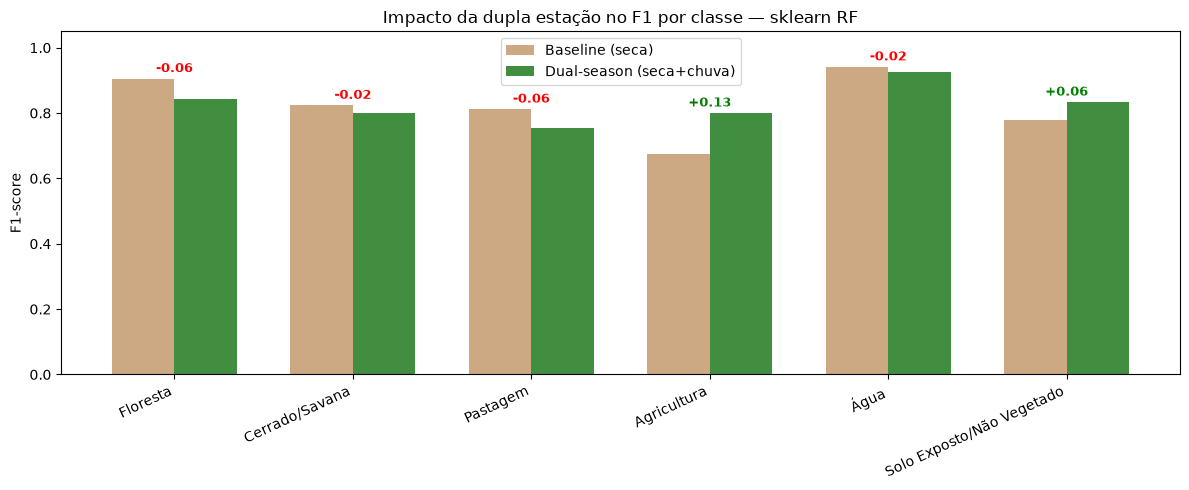

                           F1 Baseline (seca)  F1 Dual-season      Δ
Floresta                                0.905           0.842 -0.063
Cerrado/Savana                          0.824           0.800 -0.024
Pastagem                                0.812           0.753 -0.059
Agricultura                             0.675           0.800  0.125
Água                                    0.941           0.925 -0.016
Solo Exposto/Não Vegetado               0.778           0.833  0.056

Acurácia: baseline=0.824 → dual=0.825 (Δ +0.001)
Kappa:    baseline=0.788 → dual=0.789 (Δ +0.001)


In [28]:
# Comparação F1 por classe: baseline (seca) vs dual-season — usando sklearn RF
f1_base = report_rf.loc[CLASS_NAMES,   'f1-score'].values   # report_rf da Etapa 8
f1_dual = report_rf_d.loc[CLASS_NAMES, 'f1-score'].values

x = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, f1_base, width, label='Baseline (seca)',      color='#c49a6c', alpha=0.85)
b2 = ax.bar(x + width/2, f1_dual, width, label='Dual-season (seca+chuva)', color='#1f7a1f', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.05)
ax.set_title('Impacto da dupla estação no F1 por classe — sklearn RF')
ax.legend()

# Anota o delta (ganho/perda) acima de cada par
for i, (fb, fd) in enumerate(zip(f1_base, f1_dual)):
    delta = fd - fb
    ax.text(i, max(fb, fd) + 0.02, f'{delta:+.2f}',
            ha='center', fontsize=9, color='green' if delta >= 0 else 'red', weight='bold')

plt.tight_layout()
fig.savefig('../outputs/figuras/comparacao_dual_season.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo baseline vs dual
df_compare = pd.DataFrame({
    'F1 Baseline (seca)':  f1_base,
    'F1 Dual-season':      f1_dual,
    'Δ':                   f1_dual - f1_base,
}, index=CLASS_NAMES).round(3)
print(df_compare.to_string())
print(f'\nAcurácia: baseline={metrics_rf["accuracy"]:.3f} → dual={metrics_rf_d["accuracy"]:.3f} '
      f'(Δ {metrics_rf_d["accuracy"] - metrics_rf["accuracy"]:+.3f})')
print(f'Kappa:    baseline={metrics_rf["kappa"]:.3f} → dual={metrics_rf_d["kappa"]:.3f} '
      f'(Δ {metrics_rf_d["kappa"] - metrics_rf["kappa"]:+.3f})')

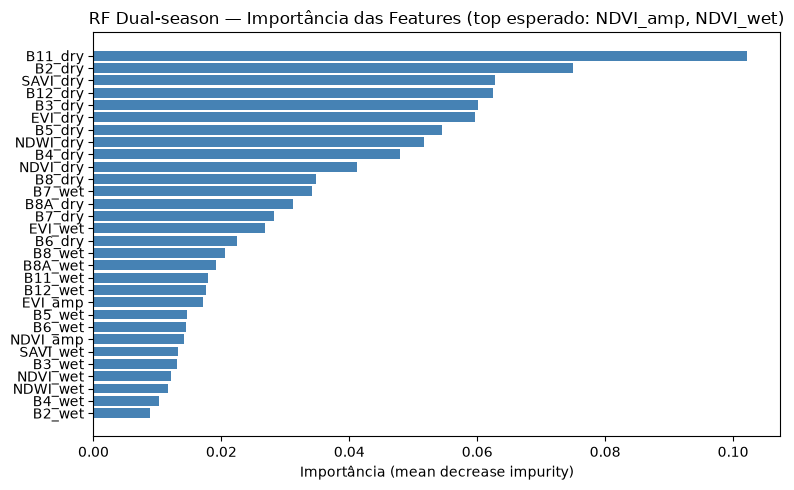

In [29]:
# Feature importance dual — onde aparecem as bandas de amplitude sazonal?
fig_imp_d = plot_feature_importance(
    rf_dual.feature_importances_, DUAL_SEASON_BANDS,
    title='RF Dual-season — Importância das Features (top esperado: NDVI_amp, NDVI_wet)',
)
fig_imp_d.savefig('../outputs/figuras/feature_importance_dual.png', dpi=150, bbox_inches='tight')
plt.show()

**Verificação:**
- **Agricultura e Solo Exposto** devem ter os maiores ganhos (Δ positivo) — eram as classes mais prejudicadas pela ambiguidade da seca
- Na importância de features, `NDVI_amp` e `NDVI_wet` devem subir para o topo — confirma que a sazonalidade é o sinal mais discriminante
- Se a chuva teve poucas cenas (`n_wet` baixo) ou muitos NaN removidos, o ganho pode ser menor — nesse caso, amplie `WET_DATES` ou aumente `max_cloud_wet`
- Se o ganho global for < 2 pontos, vale combinar com os índices BSI/NDTI (a outra alavanca) antes de partir para a documentação

---
## Etapa 11 — Teste de Generalização em Outra Cena

Aplica o modelo **treinado em Sapezal** (dual-season) a uma AOI diferente — região de
Campo Novo do Parecis (~100 km a leste), **sem re-treinar**. Isso testa se o modelo
generaliza espacialmente ou se aprendeu padrões específicos da cena de treino.

**Interpretação:** uma queda pequena de acurácia (< 5 pts) indica boa generalização.
Quedas grandes indicam *overfitting espacial* — o modelo depende de características locais
de Sapezal que não se repetem em outras regiões.

In [30]:
# Nova AOI — região de Campo Novo do Parecis (MT), ~100 km a leste de Sapezal.
# Mesma Chapada dos Parecis: mesmas 6 classes esperadas, cena geograficamente distinta.
NEW_AOI = ee.Geometry.BBox(-58.00, -13.90, -57.50, -13.40)

# Composite dual-season da nova AOI (mesmo período do treino)
new_dual = build_dual_season_composite(NEW_AOI, DRY_DATES, WET_DATES, 20, 40)
new_lulc = load_mapbiomas(NEW_AOI, MB_FROM, MB_TO, year=2023)

# Confere se todas as 6 classes existem na nova AOI (senão a comparação fica incompleta)
new_class_hist = new_lulc.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(), geometry=NEW_AOI,
    scale=30, maxPixels=1e9, bestEffort=True,
).getInfo()['lulc']
print('Classes presentes na nova AOI:')
for code_str in sorted(new_class_hist, key=lambda x: int(float(x))):
    code = int(float(code_str))
    print(f'  {code} — {LULC_CLASSES[code]["name"]}')

Classes presentes na nova AOI:
  1 — Floresta
  2 — Cerrado/Savana
  3 — Pastagem
  4 — Agricultura
  5 — Água
  6 — Solo Exposto/Não Vegetado


In [31]:
# Teste quantitativo de transferência: amostra a nova AOI e prediz com o modelo de Sapezal.
# Usa rf_dual (sklearn, treinado em Sapezal) — NÃO re-treina. Carrega do .pkl para robustez.
rf_sapezal = joblib.load('../outputs/metricas/rf_model_dual.pkl')

# Amostra a nova AOI (features dual + rótulo MapBiomas como verdade de campo)
# tile_scale=4 pelos mesmos motivos da Etapa 10 (composite dual pesado)
new_samples = stratified_sample(
    new_lulc, new_dual, NEW_AOI, n_per_class=N_PER_CLASS, tile_scale=4,
)
df_new = fc_to_dataframe(new_samples, DUAL_SEASON_BANDS).dropna().reset_index(drop=True)

X_new = df_new[DUAL_SEASON_BANDS].values
y_new = df_new['lulc'].astype(int).values
y_pred_new = rf_sapezal.predict(X_new)

metrics_new, report_new = compute_metrics(y_new, y_pred_new, CLASS_NAMES)

print(f'Amostras na nova AOI: {len(df_new)}')
print(f'\n=== Generalização: Sapezal (treino) → Campo Novo do Parecis (teste) ===')
print(f'Acurácia: {metrics_new["accuracy"]:.3f}  |  Kappa: {metrics_new["kappa"]:.3f}')

# Compara F1 por classe: teste em Sapezal vs nova cena
f1_sapezal = report_rf_d.loc[CLASS_NAMES, 'f1-score'].values   # dual, teste Sapezal (Etapa 10)
f1_newscene = report_new.loc[CLASS_NAMES, 'f1-score'].values
df_gen = pd.DataFrame({
    'F1 Sapezal (teste)':  f1_sapezal.round(3),
    'F1 Nova cena':        f1_newscene.round(3),
    'Δ (transferência)':   (f1_newscene - f1_sapezal).round(3),
}, index=CLASS_NAMES)
print('\n' + df_gen.to_string())

Amostras na nova AOI: 1200

=== Generalização: Sapezal (treino) → Campo Novo do Parecis (teste) ===
Acurácia: 0.752  |  Kappa: 0.702

                           F1 Sapezal (teste)  F1 Nova cena  Δ (transferência)
Floresta                                0.842         0.847              0.005
Cerrado/Savana                          0.800         0.649             -0.151
Pastagem                                0.753         0.685             -0.068
Agricultura                             0.800         0.716             -0.084
Água                                    0.925         0.858             -0.067
Solo Exposto/Não Vegetado               0.833         0.717             -0.117


In [32]:
# Mapa da nova cena classificado pelo modelo de Sapezal vs MapBiomas
# ⚠️ Requer gee_classifier_dual da Etapa 10 (mesma sessão)
new_classified = (
    new_dual.classify(gee_classifier_dual)
    .updateMask(new_lulc.mask())
    .rename('lulc')
)
vis_lulc = {'min': 1, 'max': 6, 'palette': [info['color'] for info in LULC_CLASSES.values()]}

Map_new = geemap.Map(zoom=11)
Map_new.centerObject(NEW_AOI, 11)

# Basemap de satélite como fundo — referência para validar as classificações.
# Aparece nas bordas e nos pixels mascarados. Para "ver através" de uma camada
# e comparar com o satélite, use o painel de camadas (canto sup. direito) e
# reduza a opacidade da camada desejada com o slider.
Map_new.add_basemap('Esri.WorldImagery')

Map_new.split_map(
    left_layer=geemap.ee_tile_layer(new_classified, vis_lulc, 'Modelo Sapezal → Nova cena'),
    right_layer=geemap.ee_tile_layer(new_lulc,       vis_lulc, 'MapBiomas 2023'),
    left_label='Modelo Sapezal', right_label='MapBiomas',
)
Map_new.add_legend(title='Classes LULC',
                   legend_dict={info['name']: info['color'] for info in LULC_CLASSES.values()},
                   position='bottomright')
Map_new

Map(center=[-13.649953390772486, -57.75000000000053], controls=(ZoomControl(options=['position', 'zoom_in_text…

**Como interpretar a transferência:**
- **Δ pequeno e negativo (−2 a −5 pts):** generalização saudável — o modelo aprendeu assinaturas espectrais reais, não decorou Sapezal
- **Δ grande negativo (> −10 pts) em classes específicas:** essas classes têm assinatura espectral diferente na nova região (ex: solo de cor diferente, cultura diferente)
- **Δ positivo:** a nova cena é "mais fácil" (classes mais separadas espectralmente) — também é um resultado válido
- O `gap de generalização` (acurácia Sapezal − acurácia nova cena) é a métrica honesta de quão transferível é o modelo para uso operacional fora da área de treino

Esta etapa fecha o desenvolvimento do modelo. Quando estiver satisfeito, seguimos para a **Etapa 12 — Documentação**.